## Imports

In [2]:
from environment import Environment
from agent import Agent

In [3]:
from tensorflow.keras.models import load_model

## Loading Trained Models

### Actor Model

In [4]:
actor_model_path=r"/home/spiralmonster/Projects/ReinforcementLearningForFinance/OptimalExecution/Models/actor_model_version_1_o.keras"

In [5]:
actor_model=load_model(actor_model_path)

2025-06-28 02:38:48.046753: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
actor_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 11, 16)    │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         48 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        144 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     24,832 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        544 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          9 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 288,197 (1.10 MB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 192,132 (750.52 KB)

### Critic Model

In [7]:
critic_model_path=r"/home/spiralmonster/Projects/ReinforcementLearningForFinance/OptimalExecution/Models/critic_model_version_1_o.keras"

In [8]:
critic_model=load_model(critic_model_path)

In [9]:
critic_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 11, 16)    │      1,152 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │         48 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        144 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 64)        │     24,832 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │        544 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     12,416 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     33,024 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     16,448 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │      1,040 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8)         │        136 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │          9 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 288,197 (1.10 MB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 192,132 (750.52 KB)

## Environment Initialization

In [10]:
env=Environment(
    number_shares=1,
    trading_time=10,
    trading_steps=10,
    stock_volatility=0.15,
    permanent_impact_factor=0.1,
    temporary_impact_factor=0.1,
    risk_aversion_factor=0.2
)

## Agent Initialization

In [11]:
penalty_weights={
    "remaining_share_penalty_weight":1,
    "action_penalty_weight":1,
    "total_execution_cost_penalty_weight":10
}

In [12]:
agent=Agent(
    env=env,
    actor_model_config=None,
    critic_model_config=None,
    actor_optimizer_config=None,
    critic_optimizer_config=None,
    actor_model_loss=None,
    critic_model_loss=None,
    gamma=0.7,
    exploration_episodes=250,
    batch_size=128,
    buffer_size=3000,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.9975,
    penalty_weights=penalty_weights,
    model_trained=True
)

## Assigning Trained Models

In [13]:
agent.actor_model=actor_model

In [14]:
agent.critic_model=critic_model

## Testing

Testing|  Total Reward: -6.092125523254716| Average Reward: -0.6092125523254717| Average Permanent Impact: 0.025538651320529467| Average Temporary Impact: 0.010387203638669688| Average Execution Risk: 0.004896194131899711| Average Total Execution Cost: 0.04082204909109886| Mean Absolute Error between Optimal Execution Strategy and Learned Strategy: 0.06174863806701671| Mean Squared Error between Real and Predicted Value of State: 0.012369003206495064|


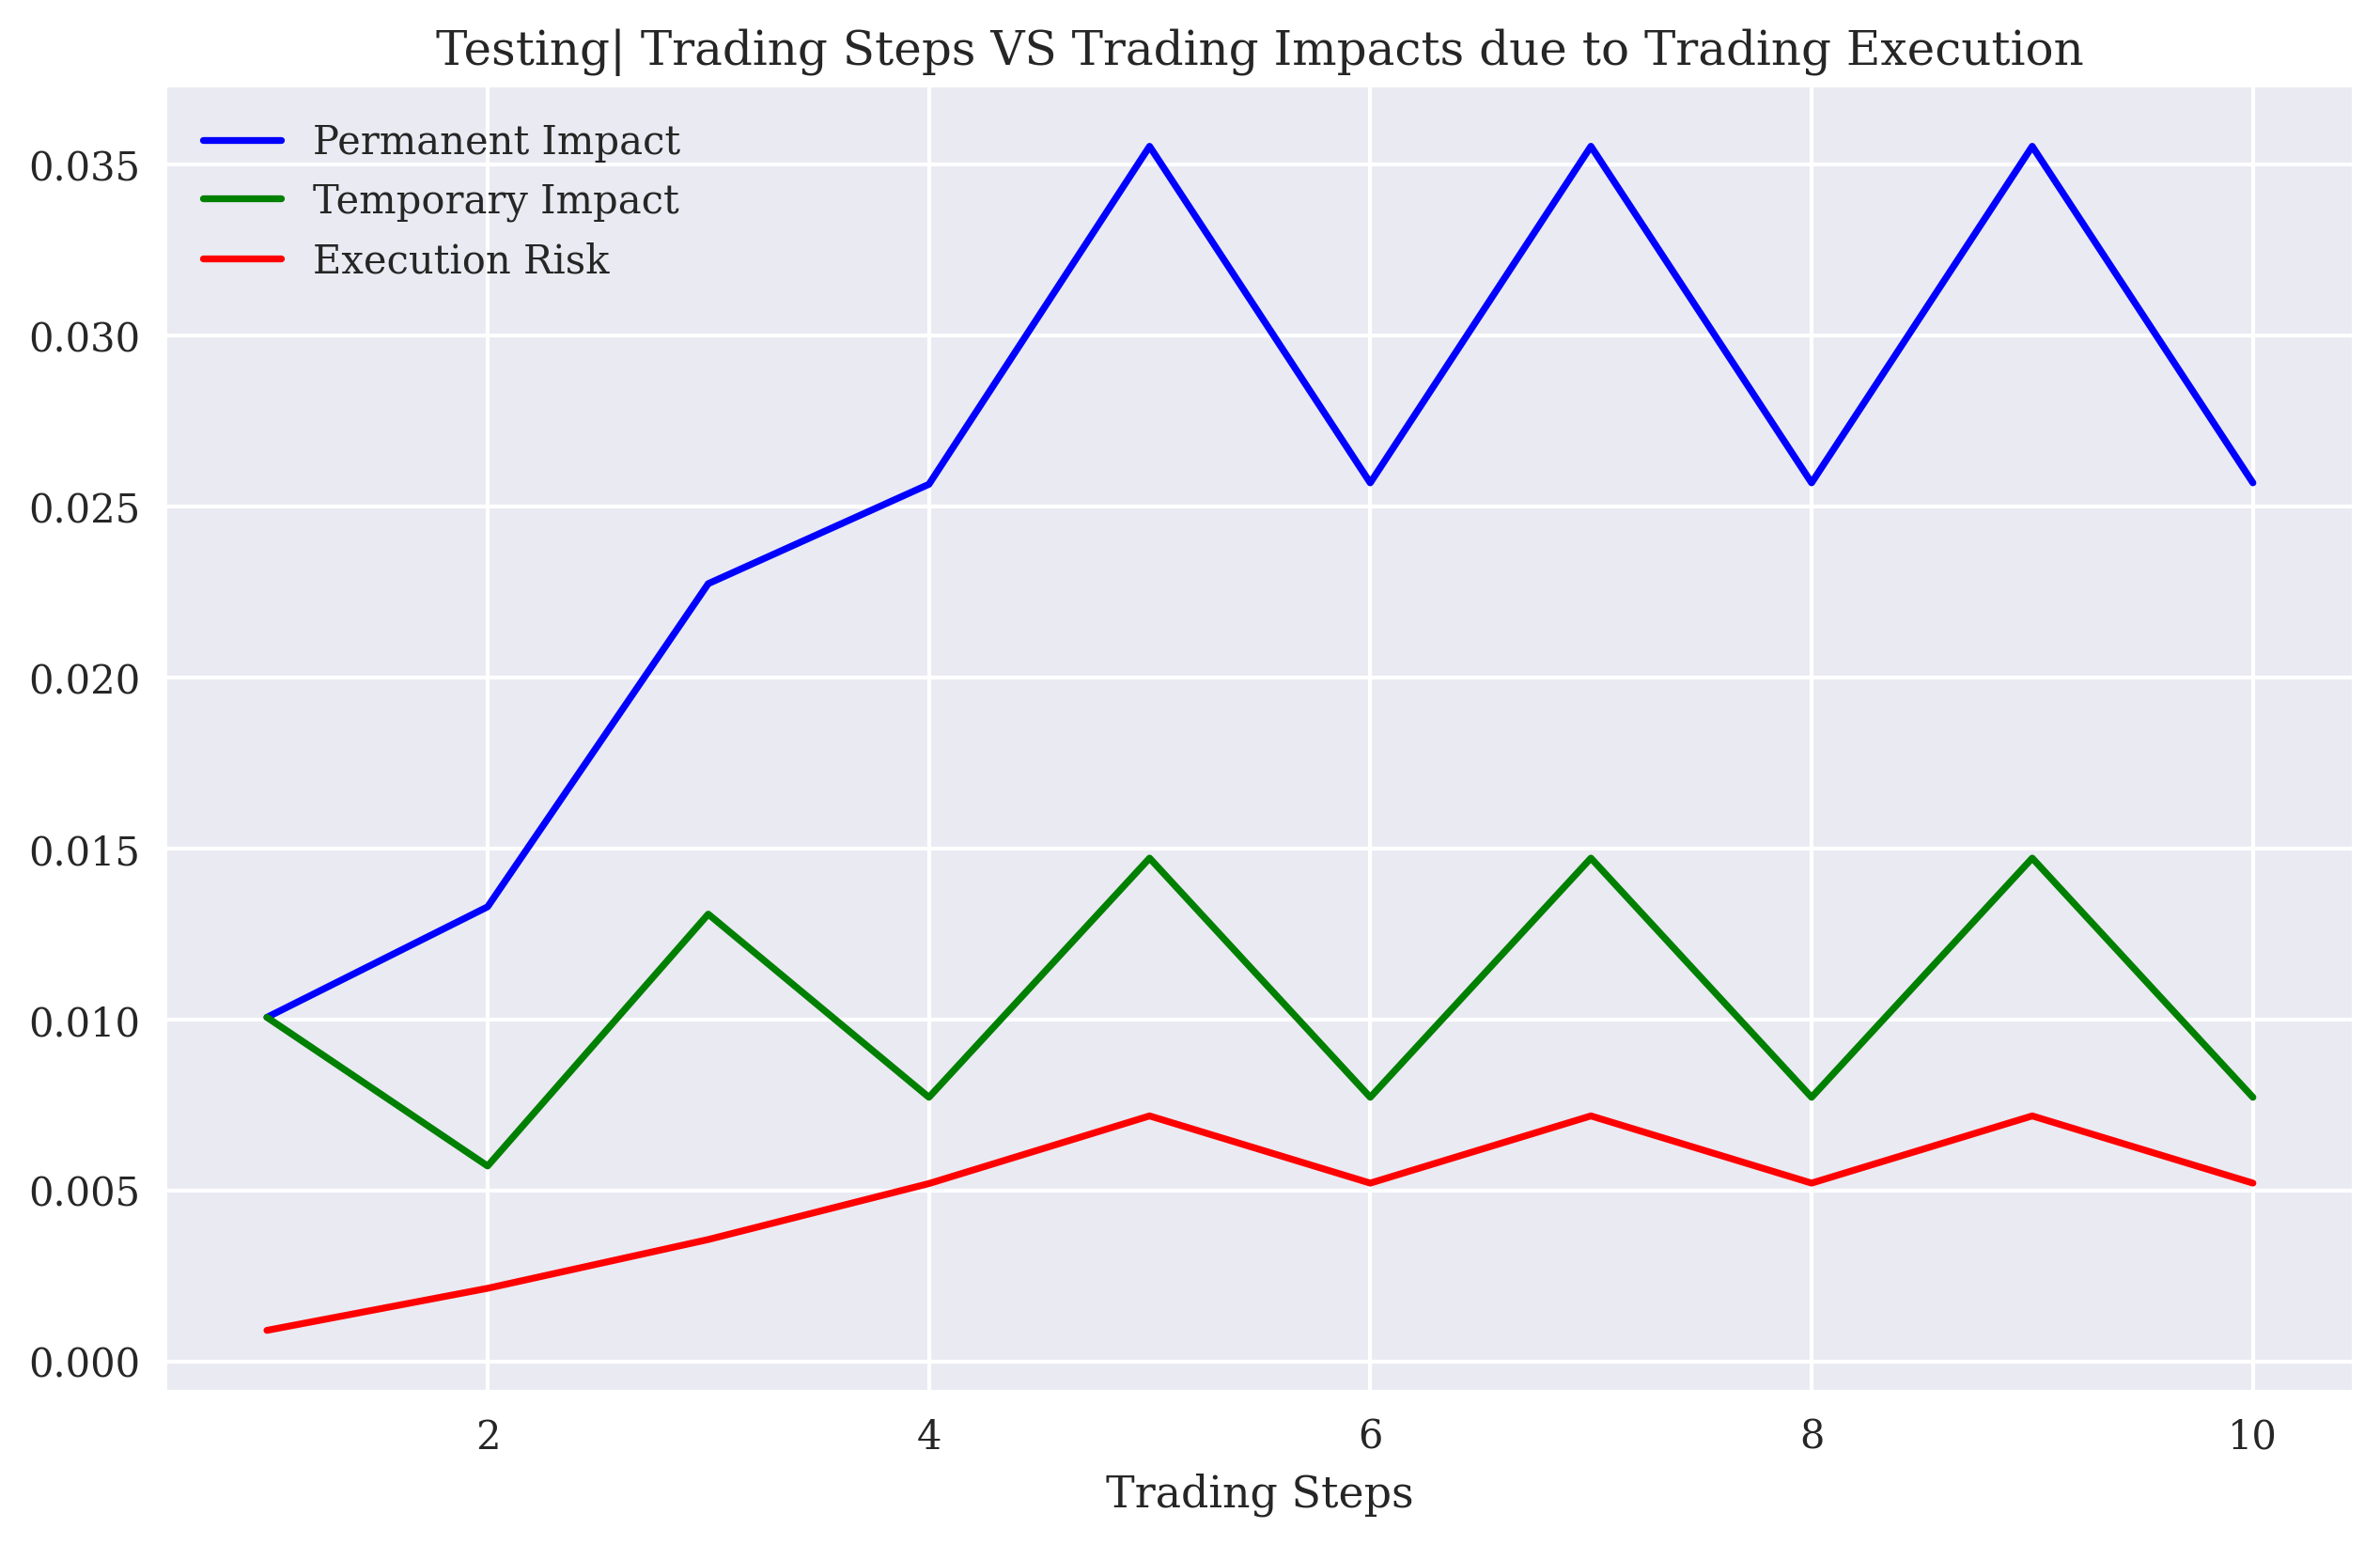

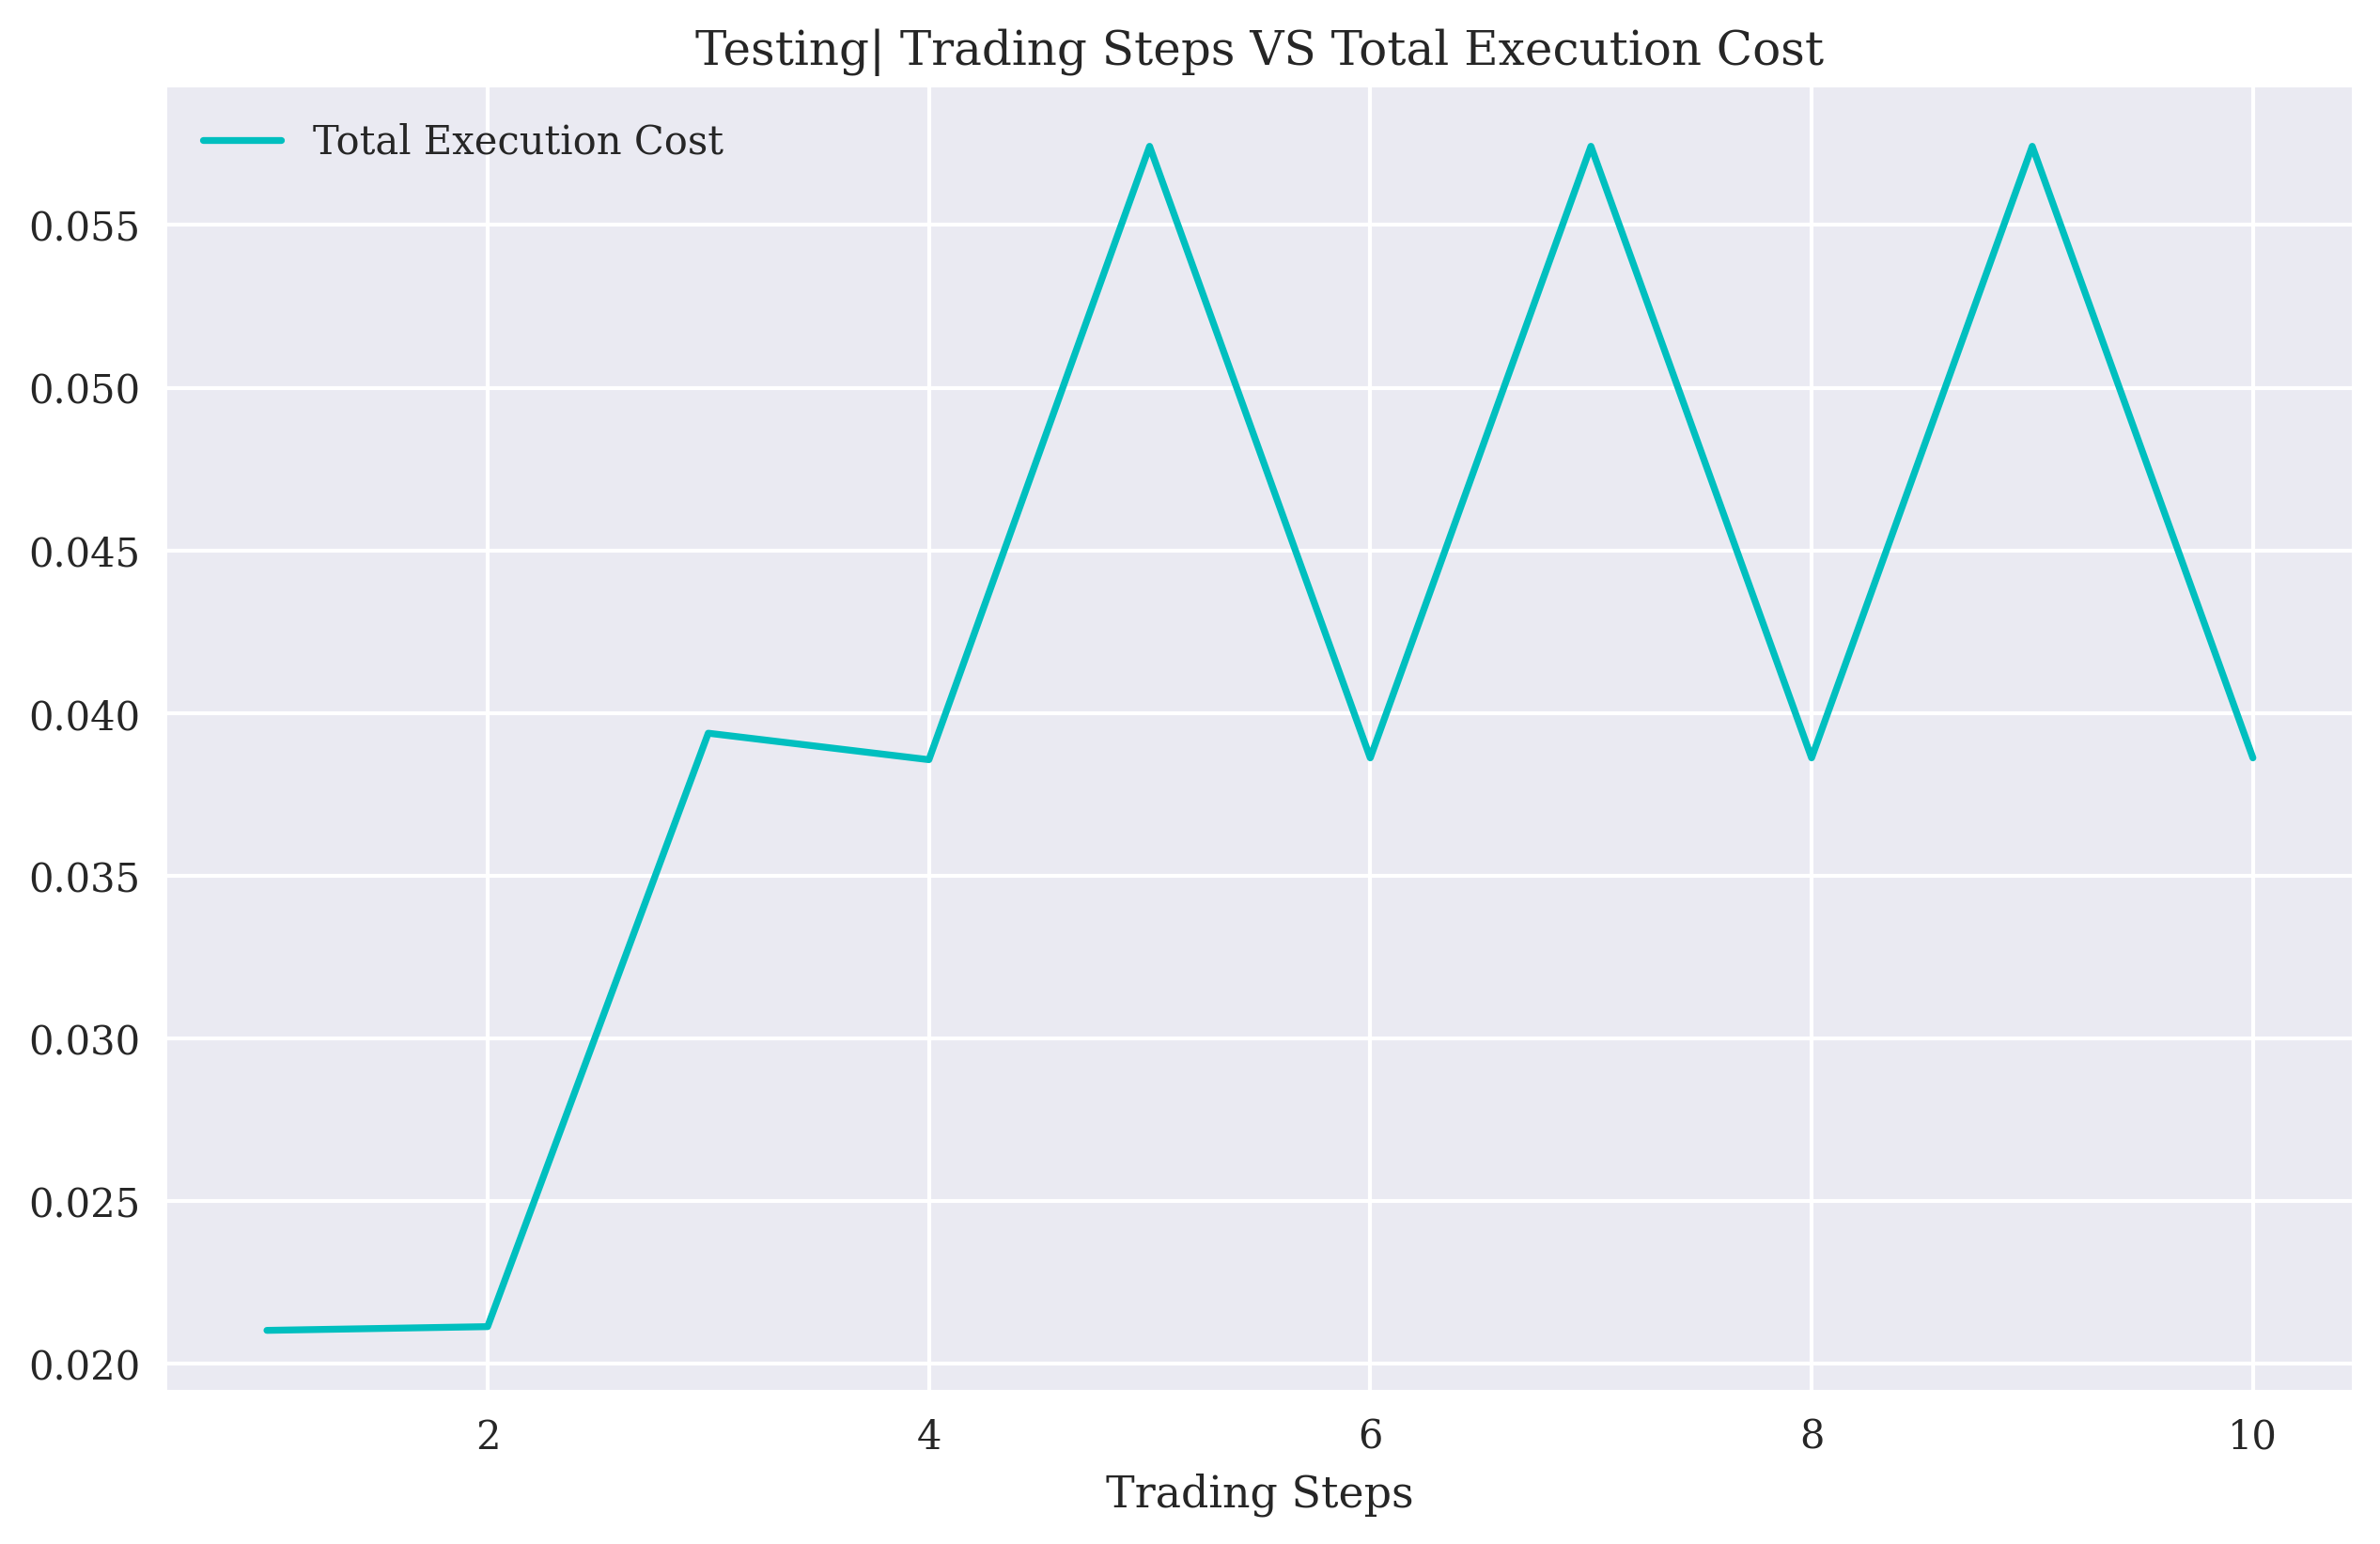

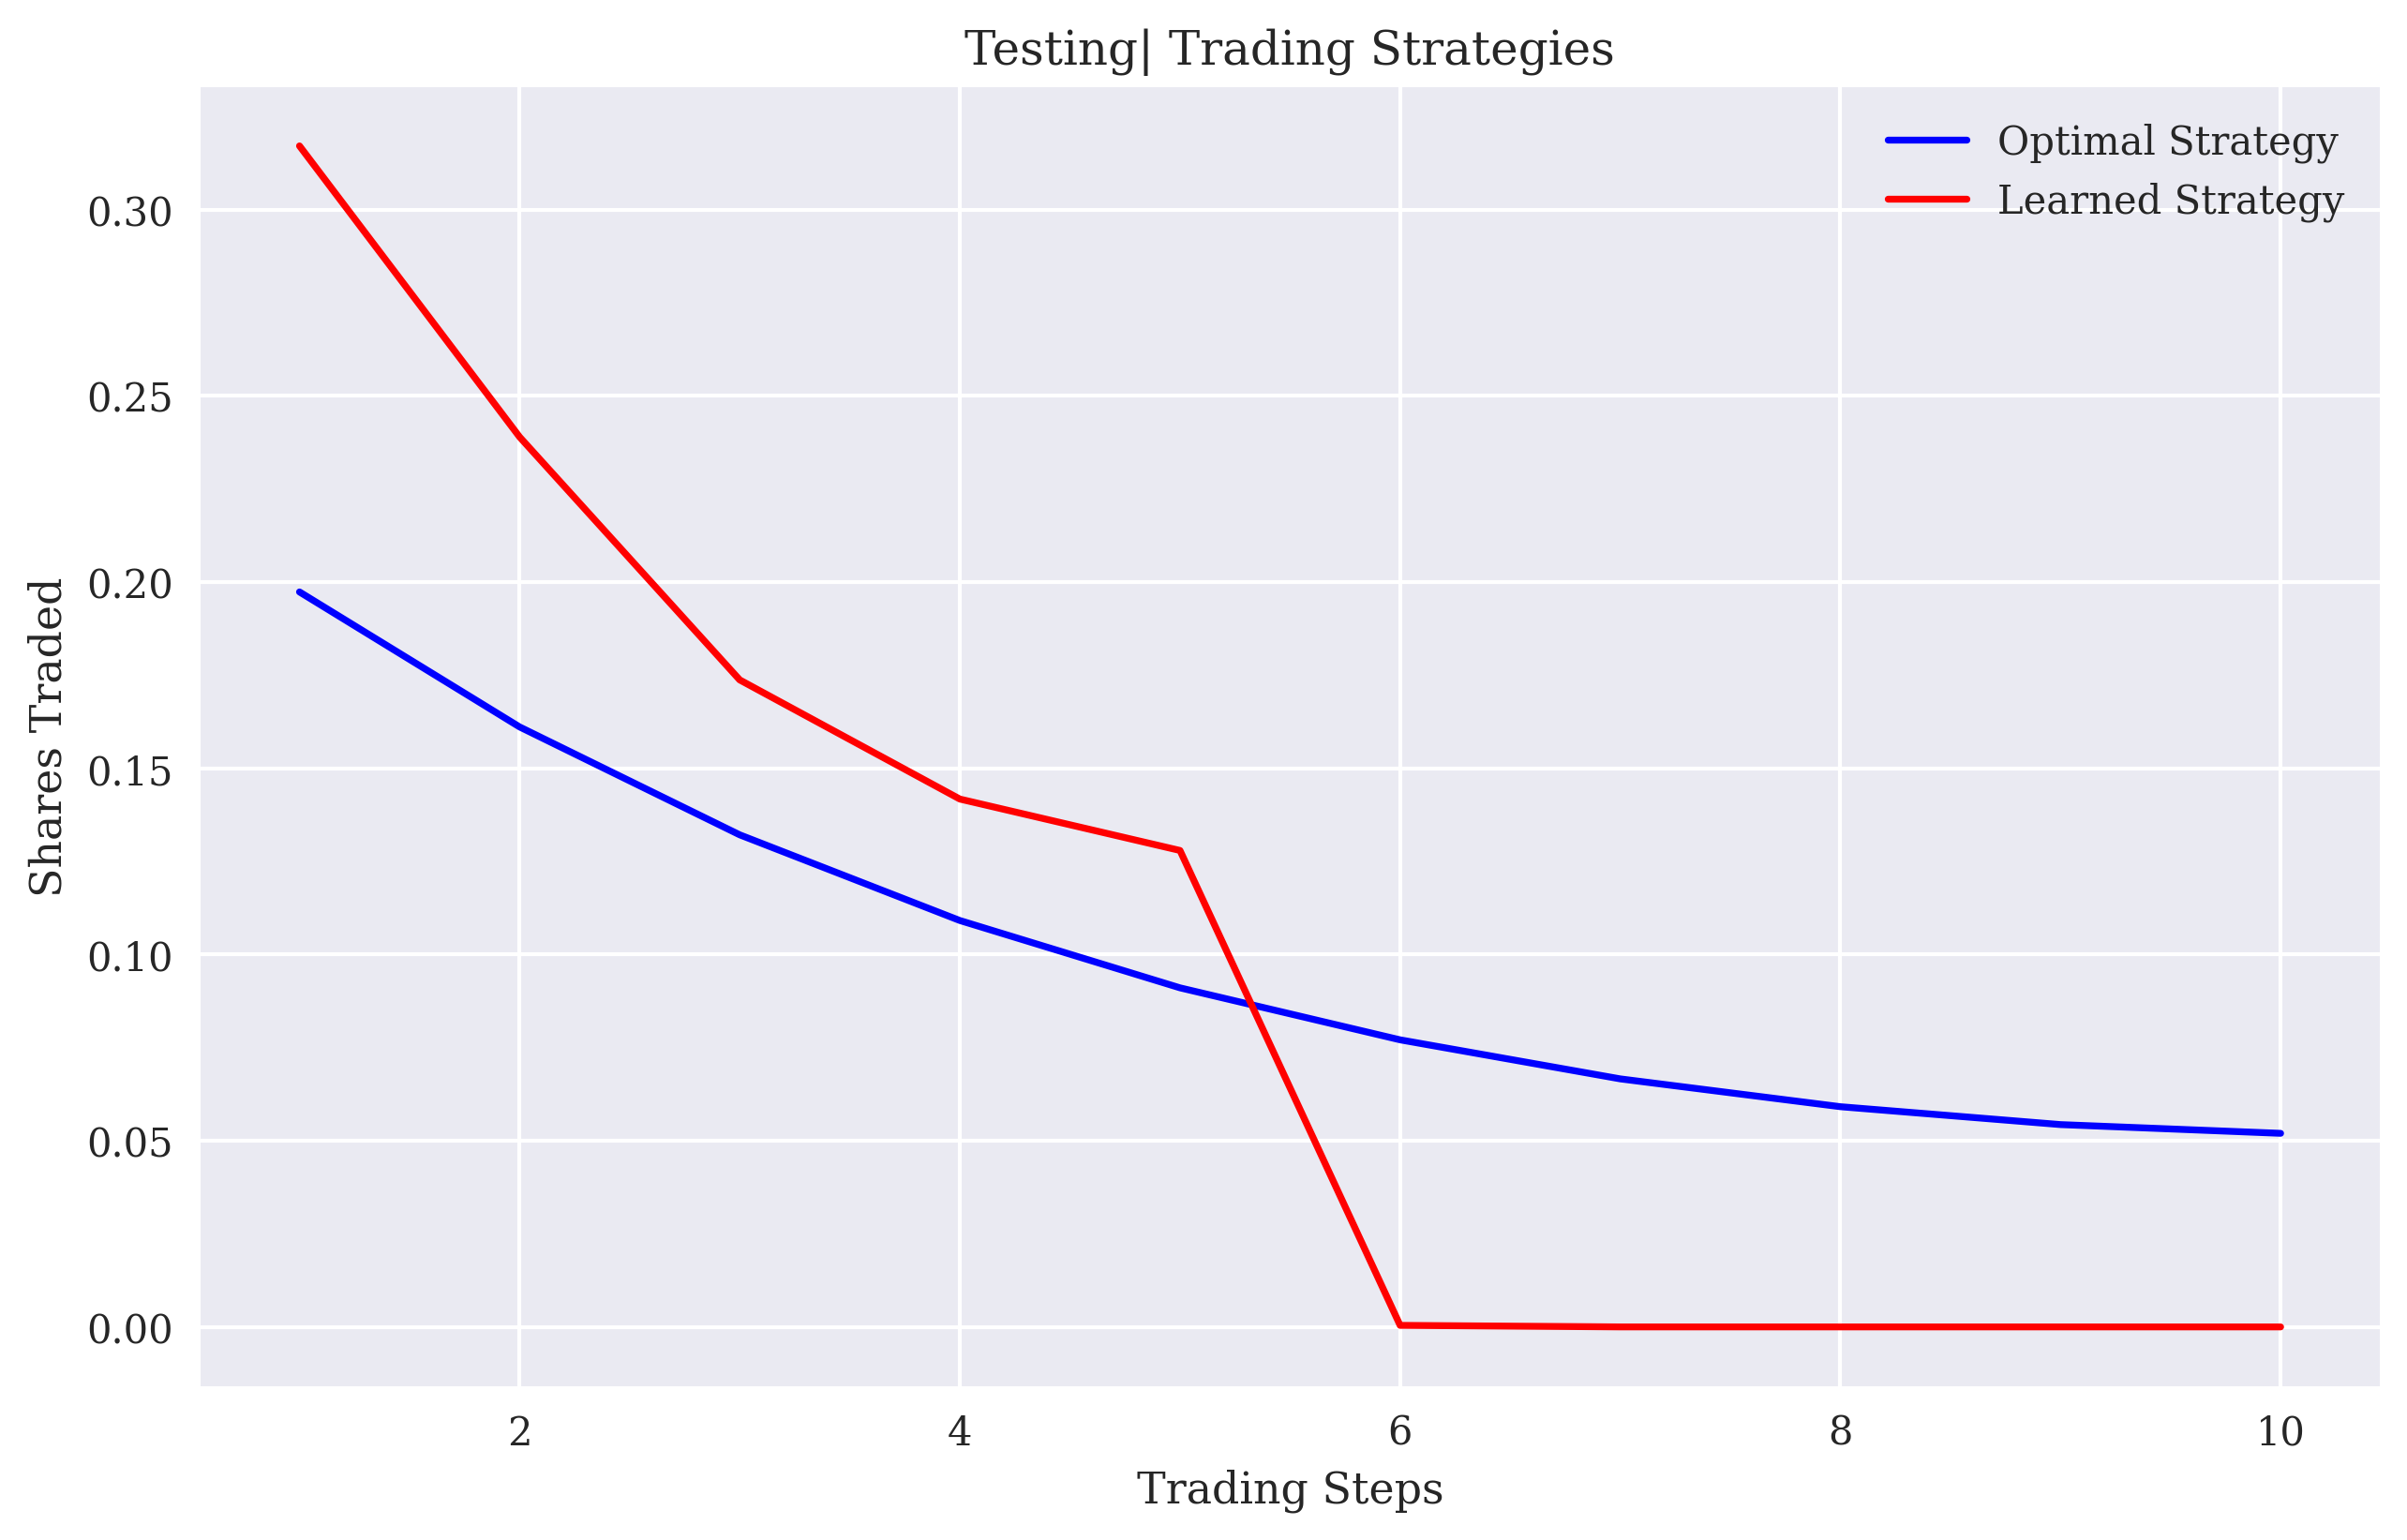

In [16]:
agent.test_agent()